# Ecuación de Schrödinger dependiente del tiempo: Oscilador Armónico Cuántico

**Física Computacional — Voluntario 3**

Resolvemos numéricamente la ecuación de Schrödinger 1D dependiente del tiempo (TDSE)
para el oscilador armónico cuántico mediante el **algoritmo de Cayley (Crank–Nicolson)**,
que aproxima el operador de evolución por una transformación de Möbius *exactamente unitaria*
y por tanto conserva la norma de la función de onda paso a paso.

Estudiamos dos tipos de condición inicial:

1. **Autofunciones del Hamiltoniano** $\phi_n$ (estados estacionarios, $n=0,1,2,3$).
2. **Paquete de onda gaussiano** $\phi(x,0)=e^{-(x-x_0)^2/2\sigma^2}$, comparado con la
   trayectoria del oscilador clásico equivalente ($m=1/2$).

Todo el cálculo (evolución, observables, figuras y GIFs) está en este notebook. El bucle
temporal usa `numba @njit` para acelerar la resolución del sistema tridiagonal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.special import eval_hermite
from numba import njit
import os

# ============================================================
# PARAMETROS DEL PROBLEMA
# Unidades reescaladas (ec. 4 de los apuntes): hbar = 1, m = 1/2.
# El Hamiltoniano es  H = -d^2/dx^2 + V(x),  con  V(x) = (omega^2/4)(x - x_c)^2.
# ============================================================

# --- Red espacial ---
L = 1.0                      # longitud de la caja
S = 1000                     # numero de subdivisiones -> S+1 = 1001 nodos
h = L / S                    # paso espacial Dx = 0.001
N = S                        # numero de intervalos
x = np.linspace(0.0, L, S + 1)   # x_j = j*h,  j = 0,...,1000

# --- Red temporal ---
dt = 1e-4                    # paso temporal Dt
T_total = 0.5                # tiempo total de simulacion
n_pasos = int(T_total / dt)  # = 5000 pasos

# --- Potencial del oscilador armonico ---
omega = 200.0                # frecuencia del oscilador
x_c = 0.5                    # centro del potencial (centro de la caja)
V_pot = (omega**2 / 4.0) * (x - x_c)**2   # V(x_j)

# --- Parametros del algoritmo de Cayley ---
# s_tilde = Dt / Dx^2  es el parametro adimensional del metodo
s_tilde = dt / h**2
# V_tilde_j = Dx^2 * V(x_j)  es el potencial adimensionalizado del sistema tridiagonal
V_tilde = h**2 * V_pot
# Diagonal (tiempo-independiente) del sistema tridiagonal:  A0_j = -2 + 2i/s_tilde - V_tilde_j
A0_diag = -2.0 + (2.0j / s_tilde) * np.ones(S + 1) - V_tilde

GUARDAR_CADA = 10            # se guarda un fotograma cada 10 pasos -> 501 frames

# Carpetas de salida (misma estructura que usa el informe LaTeX)
os.makedirs("resultados/autofunciones", exist_ok=True)
os.makedirs("resultados/gaussiana", exist_ok=True)
os.makedirs("resultados/informe", exist_ok=True)

print(f"h        = {h}")
print(f"s_tilde  = {s_tilde}   (debe ser 100.0)")
print(f"n_pasos  = {n_pasos}   (debe ser 5000)")
print(f"A0[500]  = {A0_diag[500]}")

h        = 0.001
s_tilde  = 100.00000000000001   (debe ser 100.0)
n_pasos  = 5000   (debe ser 5000)
A0[500]  = (-2+0.019999999999999997j)


## Modelo físico y algoritmo de Cayley

La solución formal de la TDSE es $\Phi(x,t)=e^{-i\hat H t}\,\Phi(x,0)$, con un operador de
evolución **unitario** que garantiza $\int|\Phi|^2dx=1$ en todo instante. El método de Euler
explícito aproxima $e^{-is\hat H}\approx 1-is\hat H$, que **no** es unitario y diverge. El
**algoritmo de Cayley** usa en su lugar la aproximación de Padé(1,1):

$$e^{-is\hat H}\;\approx\;\frac{1-\tfrac{i}{2}s\hat H_D}{1+\tfrac{i}{2}s\hat H_D},$$

que es exactamente unitaria porque $|(1-ix)/(1+ix)|=1$ para todo $x$ real. Discretizando el
Hamiltoniano con el laplaciano de tres puntos se obtiene, en cada paso, el sistema tridiagonal

$$\chi_{j+1}+\Big(-2+\tfrac{2i}{\tilde s}-\tilde V_j\Big)\chi_j+\chi_{j-1}=\tfrac{4i}{\tilde s}\,\Phi_j,
\qquad \Phi_j^{\,n+1}=\chi_j-\Phi_j^{\,n},$$

con $\tilde s=\Delta t/\Delta x^2$ y $\tilde V_j=\Delta x^2\,V(j\Delta x)$.

Se resuelve con el **algoritmo de Thomas** (dos barridos): los coeficientes $\alpha_j$ sólo
dependen del potencial y la geometría, así que se calculan **una sola vez**; los $\beta_j$ se
actualizan en cada paso. Condiciones de contorno de Dirichlet: $\Phi(0,t)=\Phi(1,t)=0$.

| Parámetro | Valor | Significado |
|---|---|---|
| $L$ | 1 | Longitud de la caja |
| $S$ | 1000 | Puntos espaciales |
| $\Delta x$ | 0.001 | Paso espacial |
| $\omega$ | 200 | Frecuencia del OAC |
| $\Delta t$ | $10^{-4}$ | Paso temporal |
| $t_{\max}$ | 0.5 | Tiempo total (5000 pasos) |
| $\tilde s$ | 100 | $\Delta t/\Delta x^2$ |

In [2]:
# ============================================================
# NUCLEO DEL ALGORITMO DE CAYLEY (acelerado con numba)
# Las funciones @njit no pueden ser metodos de clase, asi que se definen
# como funciones libres y la clase SimuladorOAC las invoca en cada paso.
# ============================================================

@njit
def calcular_alpha(A0_diag, N):
    """
    Barrido hacia atras que calcula los coeficientes alpha_j de Thomas.

    alpha_j no depende de la funcion de onda, solo del potencial y la geometria,
    asi que se calcula UNA sola vez y se reutiliza en los 5000 pasos.
    Recurrencia (con A+ = A- = 1), partiendo de alpha_{N-1} = 0 y bajando:
        gamma_j^{-1} = A0_j + alpha_j
        alpha_{j-1}  = -gamma_j
    """
    alpha = np.zeros(N + 1, dtype=np.complex128)
    for j in range(N - 1, 0, -1):
        gamma = 1.0 / (A0_diag[j] + alpha[j])
        alpha[j - 1] = -gamma
    return alpha


@njit
def paso_cayley(psi, alpha, A0_diag, s_tilde, N):
    """
    Un paso temporal del algoritmo de Cayley: phi^n -> phi^{n+1}.

    El operador (1 - isH/2)/(1 + isH/2) es exactamente unitario, de modo que
    la norma se conserva en cada iteracion. Pasos:
      1. termino independiente  b_j = (4i/s_tilde) * phi_j
      2. barrido atras  -> coeficientes beta_j
      3. barrido adelante -> chi_j   (chi_0 = chi_N = 0)
      4. actualizacion  phi_j^{n+1} = chi_j - phi_j^n
    """
    factor = 4.0j / s_tilde

    # --- barrido hacia atras: beta ---
    beta = np.zeros(N + 1, dtype=np.complex128)
    for j in range(N - 1, 0, -1):
        b_j = factor * psi[j]
        gamma = 1.0 / (A0_diag[j] + alpha[j])
        beta[j - 1] = gamma * (b_j - beta[j])

    # --- barrido hacia adelante: chi ---
    chi = np.zeros(N + 1, dtype=np.complex128)
    for j in range(N):
        chi[j + 1] = alpha[j] * chi[j] + beta[j]

    # --- actualizacion phi^{n+1} = chi - phi^n ---
    psi_nueva = chi - psi
    psi_nueva[0] = 0.0
    psi_nueva[N] = 0.0
    return psi_nueva

In [3]:
# ============================================================
# CLASE SIMULADOR DEL OSCILADOR ARMONICO CUANTICO
# Guarda la funcion de onda y ofrece: constructores de condiciones iniciales,
# observables fisicos y el bucle de evolucion temporal.
# ============================================================

class SimuladorOAC:
    def __init__(self, psi, alpha=None):
        """psi: array complejo (N+1,) con la funcion de onda. alpha: coeficientes de Thomas."""
        self.psi = psi.astype(np.complex128)
        self.alpha = alpha

    # ---- Condiciones iniciales (constructores) ----
    @classmethod
    def autofuncion(cls, n, alpha=None):
        """
        Autofuncion phi_n del OAC:  phi_n(x) = N_n * H_n(u) * exp(-u^2/2),
        con u = sqrt(omega/2)*(x - x_c) y H_n los polinomios de Hermite.
        Se normaliza numericamente en la red (estable tambien para n grande).
        """
        u = np.sqrt(omega / 2.0) * (x - x_c)
        psi = eval_hermite(n, u) * np.exp(-0.5 * u**2)
        psi[0] = 0.0
        psi[-1] = 0.0
        psi = psi / np.sqrt(h * np.sum(np.abs(psi)**2))
        return cls(psi.astype(np.complex128), alpha)

    @classmethod
    def gaussiana(cls, x0, sigma, alpha=None):
        """
        Paquete gaussiano  phi(x,0) = exp(-(x-x0)^2 / (2 sigma^2)), normalizado.
        No es autofuncion: es superposicion de autoestados y evoluciona en el tiempo.
        """
        psi = np.exp(-(x - x0)**2 / (2.0 * sigma**2))
        psi[0] = 0.0
        psi[-1] = 0.0
        psi = psi / np.sqrt(h * np.sum(np.abs(psi)**2))
        return cls(psi.astype(np.complex128), alpha)

    # ---- Observables (integrales aproximadas por sumas de Riemann, factor h) ----
    def norma(self):
        """Norma  N = h * sum |psi|^2.  Debe ser 1 en todo instante."""
        return h * np.sum(np.abs(self.psi)**2)

    def valor_medio_x(self):
        """<x> = h * sum x_j |psi_j|^2.  Para autofunciones vale x_c = 0.5."""
        return h * np.sum(x * np.abs(self.psi)**2)

    def valor_medio_p(self):
        """<p> = h * sum psi* (-i) dpsi/dx, con diferencias centradas.  Para autofunciones vale 0."""
        psi = self.psi
        dpsi = (psi[2:] - psi[:-2]) / (2.0 * h)
        return float(h * np.sum(np.conj(psi[1:-1]) * (-1j) * dpsi).real)

    def valor_medio_H(self):
        """<H> = h * sum psi* (H_D psi), con (H_D psi)_j = -(psi_{j+1}-2psi_j+psi_{j-1})/h^2 + V_j psi_j."""
        psi = self.psi
        lap = -(psi[2:] - 2.0 * psi[1:-1] + psi[:-2]) / h**2
        Hpsi = lap + V_pot[1:-1] * psi[1:-1]
        return float(h * np.sum(np.conj(psi[1:-1]) * Hpsi).real)

    def incertidumbre_x(self):
        """Dx = sqrt(<x^2> - <x>^2)."""
        psi = self.psi
        x2 = h * np.sum(x**2 * np.abs(psi)**2)
        xm = h * np.sum(x * np.abs(psi)**2)
        return np.sqrt(max(x2 - xm**2, 0.0))

    def incertidumbre_p(self):
        """Dp = sqrt(<p^2> - <p>^2), con <p^2> = h * sum psi* (-laplaciano)."""
        psi = self.psi
        lap = -(psi[2:] - 2.0 * psi[1:-1] + psi[:-2]) / h**2
        p2 = float(h * np.sum(np.conj(psi[1:-1]) * lap).real)
        pm = self.valor_medio_p()
        return np.sqrt(max(p2 - pm**2, 0.0))

    # ---- Evolucion temporal ----
    def paso(self):
        """Avanza un paso de Cayley llamando a la rutina acelerada con numba."""
        self.psi = paso_cayley(self.psi, self.alpha, A0_diag, s_tilde, N)

    def evolucionar(self, n_pasos, guardar_cada=10):
        """
        Ejecuta n_pasos pasos de Cayley, registra los observables en cada paso y
        guarda un fotograma de la funcion de onda cada 'guardar_cada' pasos.
        Devuelve un diccionario con todas las series temporales y los fotogramas.
        """
        tiempos = np.arange(n_pasos + 1) * dt
        normas = np.zeros(n_pasos + 1)
        x_meds = np.zeros(n_pasos + 1)
        p_meds = np.zeros(n_pasos + 1)
        H_meds = np.zeros(n_pasos + 1)
        dxdps = np.zeros(n_pasos + 1)

        n_frames = n_pasos // guardar_cada + 1
        frames = np.zeros((n_frames, N + 1), dtype=np.complex128)
        t_frames = np.zeros(n_frames)

        def registrar(i):
            normas[i] = self.norma()
            x_meds[i] = self.valor_medio_x()
            p_meds[i] = self.valor_medio_p()
            H_meds[i] = self.valor_medio_H()
            dxdps[i] = self.incertidumbre_x() * self.incertidumbre_p()

        registrar(0)
        frames[0] = self.psi.copy()
        t_frames[0] = 0.0
        fi = 1

        for step in range(1, n_pasos + 1):
            self.paso()
            registrar(step)
            if step % guardar_cada == 0 and fi < n_frames:
                frames[fi] = self.psi.copy()
                t_frames[fi] = step * dt
                fi += 1

        return {"tiempos": tiempos, "normas": normas, "x_meds": x_meds,
                "p_meds": p_meds, "H_meds": H_meds, "dxdps": dxdps,
                "frames": frames, "t_frames": t_frames}

In [4]:
# ============================================================
# VALORES TEORICOS DE REFERENCIA (para comparar con la simulacion)
# ============================================================

def energias(n_list):
    """Autovalores del OAC:  E_n = omega (n + 1/2)."""
    return np.array([omega * (n + 0.5) for n in n_list])

def heisenberg_dxdp(n_list):
    """Producto de incertidumbres de cada autoestado:  (Dx Dp)_n = (2n+1)/2.  Minimo en n=0."""
    return np.array([(2 * n + 1) / 2.0 for n in n_list])

def trayectoria_clasica(t_array, x0, p0):
    """
    Trayectoria exacta del oscilador clasico con m = 1/2:
        x_cl(t) = x_c + (x0-x_c) cos(omega t) + (2 p0/omega) sin(omega t)
        p_cl(t) = -(omega/2)(x0-x_c) sin(omega t) + p0 cos(omega t)
    Por el teorema de Ehrenfest (exacto para V cuadratico), <x(t)> y <p(t)> la siguen.
    """
    x_cl = x_c + (x0 - x_c) * np.cos(omega * t_array) + (2 * p0 / omega) * np.sin(omega * t_array)
    p_cl = -(omega / 2.0) * (x0 - x_c) * np.sin(omega * t_array) + p0 * np.cos(omega * t_array)
    return x_cl, p_cl

def probabilidad_clasica(x_array, E):
    """
    Distribucion clasica del OAC:  P_cl(x) = 1 / (pi sqrt(A^2 - (x-x_c)^2)),  A = 2 sqrt(E)/omega.
    La particula clasica pasa mas tiempo cerca de los puntos de retorno (velocidad baja).
    """
    A = 2.0 * np.sqrt(E) / omega
    P = np.zeros_like(x_array)
    mask = np.abs(x_array - x_c) < A
    P[mask] = 1.0 / (np.pi * np.sqrt(A**2 - (x_array[mask] - x_c)**2))
    return P

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # paleta para n = 0,1,2,3

---
# Parte 1: Autofunciones del Hamiltoniano

Las autofunciones $\phi_n$ son **estados estacionarios**: evolucionan como
$\Phi(x,t)=\phi_n(x)\,e^{-iE_nt}$, de modo que su densidad de probabilidad $|\Phi|^2$ no
cambia con el tiempo aunque las partes real e imaginaria roten. Verificaremos la conservación
de la norma y de la energía, el principio de incertidumbre $\Delta x\,\Delta p=(2n+1)/2$ y,
para $n$ grande, el **principio de correspondencia de Bohr**.

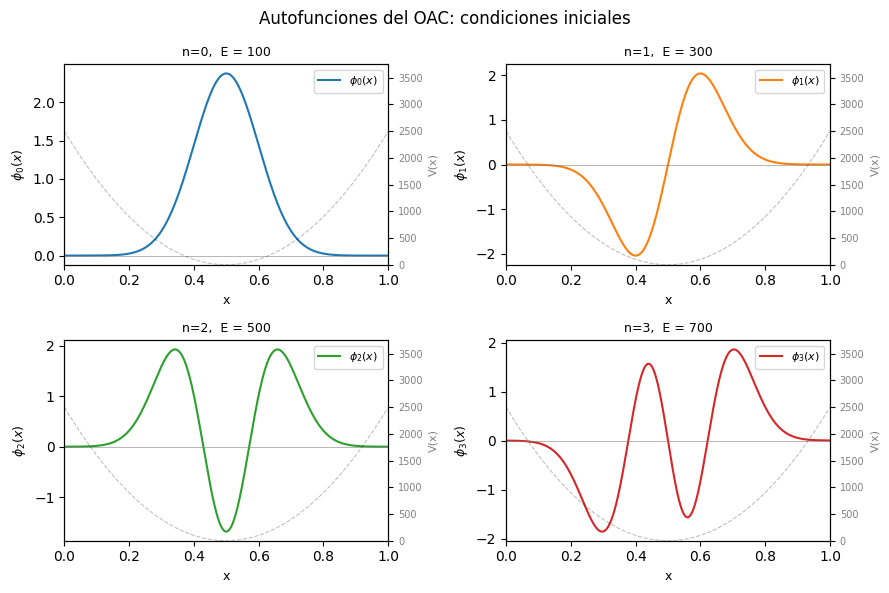

In [5]:
# Figura 1: las cuatro primeras autofunciones con el potencial superpuesto
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
fig.suptitle('Autofunciones del OAC: condiciones iniciales', fontsize=12)

for n in range(4):
    ax = axes[n // 2][n % 2]
    psi = SimuladorOAC.autofuncion(n).psi
    En = omega * (n + 0.5)

    ax.plot(x, psi.real, color=COLORS[n], linewidth=1.5, label=fr'$\phi_{n}(x)$')
    ax2 = ax.twinx()
    ax2.plot(x, V_pot, 'k--', alpha=0.25, linewidth=0.8)
    ax2.set_ylabel('V(x)', color='gray', fontsize=8)
    ax2.set_ylim(0, V_pot.max() * 1.5)
    ax2.tick_params(axis='y', labelcolor='gray', labelsize=7)

    ax.axhline(0, color='gray', linewidth=0.4)
    ax.set_xlim(0, 1)
    ax.set_xlabel('x', fontsize=9)
    ax.set_ylabel(fr'$\phi_{n}(x)$', fontsize=9)
    ax.set_title(f'n={n},  E = {En:.0f}', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('resultados/informe/fig01_autofunciones_iniciales.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Evolucion temporal de las autofunciones n = 0,1,2,3
# Se calcula alpha una sola vez y se hace un warm-up para compilar numba.
alpha = calcular_alpha(A0_diag, N)
_ = paso_cayley(SimuladorOAC.autofuncion(0, alpha).psi, alpha, A0_diag, s_tilde, N)

res_af = {}
for n in range(4):
    sim = SimuladorOAC.autofuncion(n, alpha)
    datos = sim.evolucionar(n_pasos, GUARDAR_CADA)
    res_af[n] = datos

    pre = f'resultados/autofunciones/n{n}'
    for clave in ['tiempos', 'normas', 'x_meds', 'p_meds', 'H_meds', 'dxdps', 'frames', 't_frames']:
        np.save(f'{pre}_{clave}.npy', datos[clave])

    En = omega * (n + 0.5)
    print(f"n={n}: norma_err={np.max(np.abs(datos['normas']-1)):.1e}  "
          f"<H>={datos['H_meds'].mean():.3f} (teo {En:.0f})  "
          f"DxDp={datos['dxdps'].mean():.4f} (teo {(2*n+1)/2:.2f})")

n=0: norma_err=5.4e-13  <H>=99.999 (teo 100)  DxDp=0.5000 (teo 0.50)


n=1: norma_err=6.7e-13  <H>=299.997 (teo 300)  DxDp=1.5000 (teo 1.50)


n=2: norma_err=6.7e-13  <H>=499.992 (teo 500)  DxDp=2.5000 (teo 2.50)


n=3: norma_err=1.4e-12  <H>=699.987 (teo 700)  DxDp=3.4999 (teo 3.50)


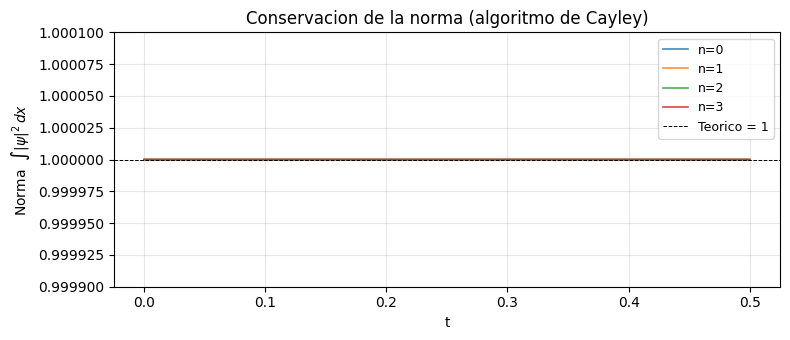

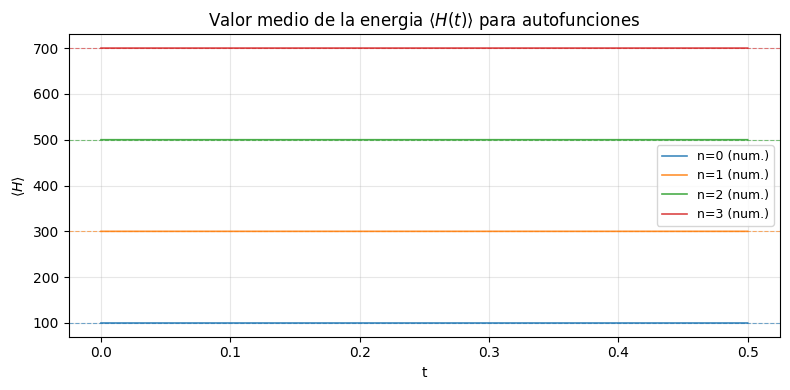

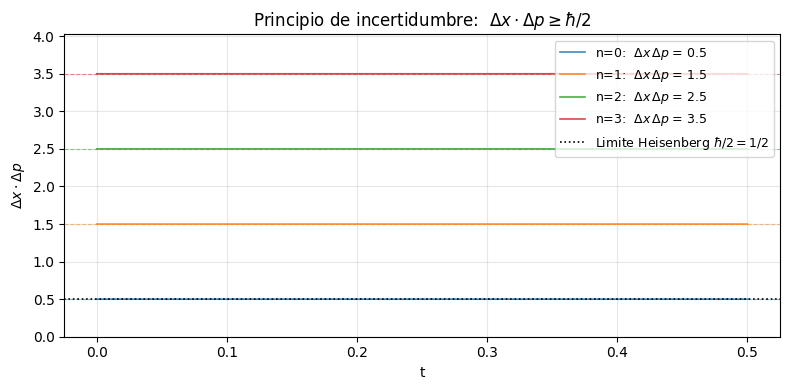

In [7]:
# Figura 2: conservacion de la norma para los cuatro estados
fig, ax = plt.subplots(figsize=(8, 3.5))
for n in range(4):
    ax.plot(res_af[n]['tiempos'], res_af[n]['normas'], color=COLORS[n], linewidth=1.2,
            label=f'n={n}', alpha=0.85)
ax.axhline(1.0, color='k', linewidth=0.7, linestyle='--', label='Teorico = 1')
ax.set_xlabel('t'); ax.set_ylabel(r'Norma  $\int|\psi|^2\,dx$')
ax.set_title('Conservacion de la norma (algoritmo de Cayley)')
ax.legend(fontsize=9); ax.set_ylim(0.9999, 1.0001)
ax.ticklabel_format(useOffset=False); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig02_norma_vs_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

# Figura 3: energia media <H(t)> con los valores teoricos E_n
En = energias(range(4))
fig, ax = plt.subplots(figsize=(8, 4))
for n in range(4):
    ax.plot(res_af[n]['tiempos'], res_af[n]['H_meds'], color=COLORS[n], linewidth=1.2,
            label=f'n={n} (num.)', alpha=0.85)
    ax.axhline(En[n], color=COLORS[n], linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('t'); ax.set_ylabel(r'$\langle H \rangle$')
ax.set_title(r'Valor medio de la energia $\langle H(t)\rangle$ para autofunciones')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig03_energia_vs_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()

# Figura 4: principio de incertidumbre  Dx*Dp = (2n+1)/2
dxdp_teo = heisenberg_dxdp(range(4))
fig, ax = plt.subplots(figsize=(8, 4))
for n in range(4):
    ax.plot(res_af[n]['tiempos'], res_af[n]['dxdps'], color=COLORS[n], linewidth=1.2,
            label=fr'n={n}:  $\Delta x\,\Delta p$ = {dxdp_teo[n]:.1f}', alpha=0.85)
    ax.axhline(dxdp_teo[n], color=COLORS[n], linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0.5, color='k', linewidth=1.2, linestyle=':', label=r'Limite Heisenberg $\hbar/2=1/2$')
ax.set_xlabel('t'); ax.set_ylabel(r'$\Delta x\cdot\Delta p$')
ax.set_title(r'Principio de incertidumbre:  $\Delta x\cdot\Delta p \geq \hbar/2$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, dxdp_teo[3] * 1.15)
plt.tight_layout()
plt.savefig('resultados/informe/fig04_heisenberg.png', dpi=150, bbox_inches='tight')
plt.show()

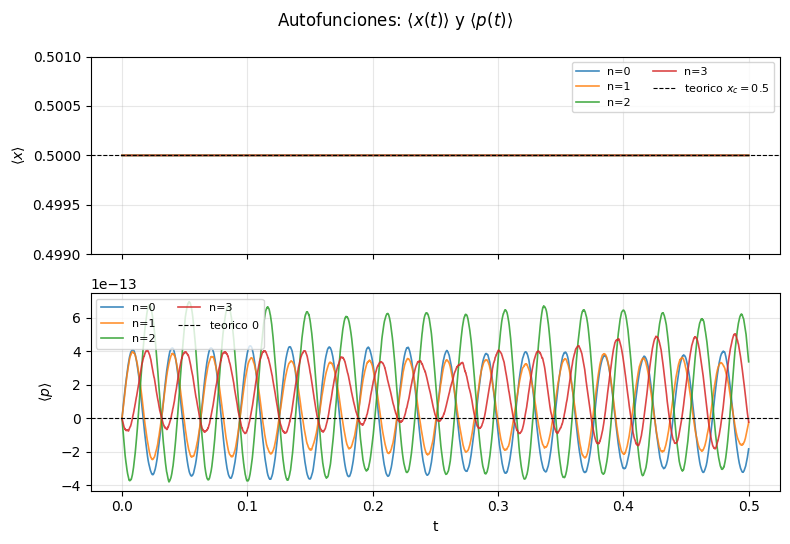

In [8]:
# Figura: <x(t)> y <p(t)> de las autofunciones (deben ser constantes 0.5 y 0)
fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
fig.suptitle(r'Autofunciones: $\langle x(t)\rangle$ y $\langle p(t)\rangle$', fontsize=12)
for n in range(4):
    d = res_af[n]
    axes[0].plot(d['tiempos'], d['x_meds'], color=COLORS[n], linewidth=1.2, label=f'n={n}', alpha=0.85)
    axes[1].plot(d['tiempos'], d['p_meds'], color=COLORS[n], linewidth=1.2, label=f'n={n}', alpha=0.85)
axes[0].axhline(0.5, color='k', linewidth=0.8, linestyle='--', label=r'teorico $x_c=0.5$')
axes[0].set_ylabel(r'$\langle x\rangle$'); axes[0].set_ylim(0.5 - 1e-3, 0.5 + 1e-3)
axes[0].ticklabel_format(axis='y', useOffset=False); axes[0].legend(fontsize=8, ncol=2); axes[0].grid(True, alpha=0.3)
axes[1].axhline(0.0, color='k', linewidth=0.8, linestyle='--', label=r'teorico $0$')
axes[1].set_ylabel(r'$\langle p\rangle$'); axes[1].set_xlabel('t')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig_autofunc_xp.png', dpi=150, bbox_inches='tight')
plt.show()

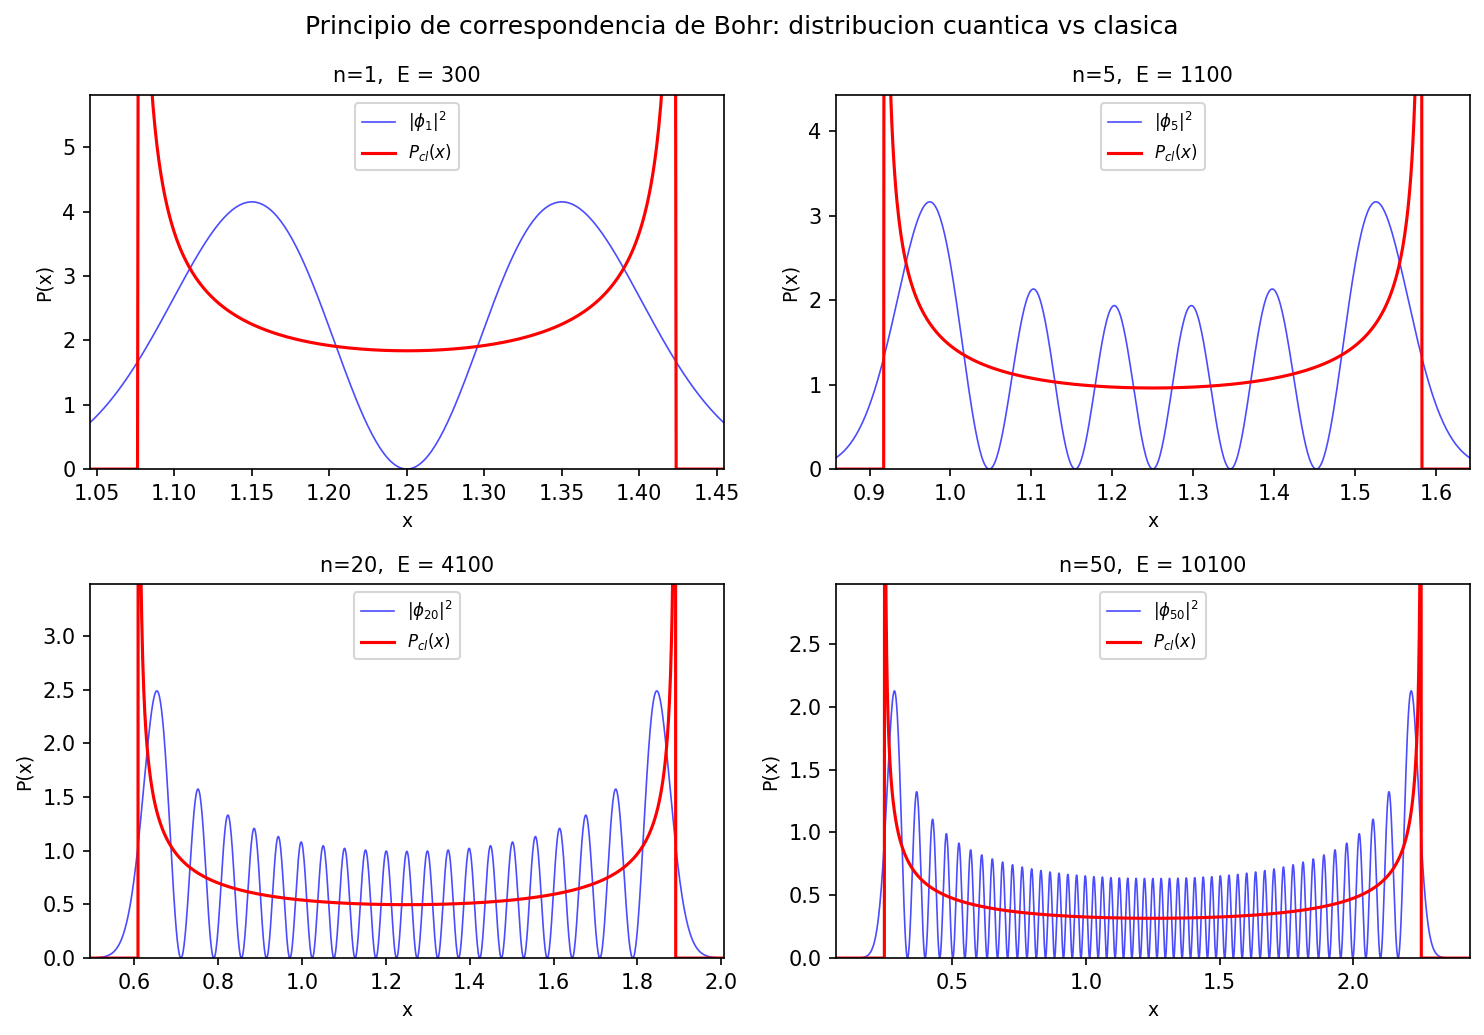

In [9]:
# Figura 5: principio de correspondencia de Bohr  |phi_n|^2  vs  P_cl(x)
# Se usa una caja mayor (L=2.5, centro x_c=1.25) para que la region clasica
# [x_c-A, x_c+A] quede contenida tambien para n grande (A_50 ~ 1.0 > 0.5); asi
# ambas densidades se normalizan de forma consistente y son comparables.
ns = [1, 5, 20, 50]
L_b = 2.5; N_b = 2000; xc_b = L_b / 2.0
xb = np.linspace(0.0, L_b, N_b + 1); hb = xb[1] - xb[0]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle('Principio de correspondencia de Bohr: distribucion cuantica vs clasica', fontsize=12)

for idx, n in enumerate(ns):
    ax = axes[idx // 2][idx % 2]
    En = omega * (n + 0.5)
    A = 2.0 * np.sqrt(En) / omega                     # amplitud clasica
    u = np.sqrt(omega / 2.0) * (xb - xc_b)
    psi = eval_hermite(n, u) * np.exp(-0.5 * u**2)
    psi = psi / np.sqrt(hb * np.sum(psi**2))          # normalizada en la caja grande
    P_q = psi**2                                      # densidad cuantica
    P_cl = np.zeros_like(xb)                           # densidad clasica
    m = np.abs(xb - xc_b) < A
    P_cl[m] = 1.0 / (np.pi * np.sqrt(A**2 - (xb[m] - xc_b)**2))

    ax.plot(xb, P_q, 'b-', linewidth=0.8, alpha=0.7, label=fr'$|\phi_{{{n}}}|^2$')
    ax.plot(xb, P_cl, 'r-', linewidth=1.5, label=r'$P_{cl}(x)$')
    margen = 0.18 * A
    ax.set_xlim(xc_b - A - margen, xc_b + A + margen)
    tope = P_cl[(P_cl > 0)]
    ax.set_ylim(0, min(P_q.max() * 1.4, tope.max() * 1.2 if tope.size else P_q.max() * 2))
    ax.set_xlabel('x', fontsize=9); ax.set_ylabel('P(x)', fontsize=9)
    ax.set_title(f'n={n},  E = {En:.0f}', fontsize=10); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('resultados/informe/fig05_correspondencia_bohr.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# GENERACION DE GIFS (Re/Im y densidad de probabilidad)
# ============================================================

def gif_reIm(frames, t_frames, titulo, filepath, fps=20):
    """GIF de Re[psi] e Im[psi]: en un estado estacionario rotan mientras |psi|^2 no cambia."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ymax = max(np.max(np.abs(frames.real)), np.max(np.abs(frames.imag))) * 1.1
    ax.set_xlim(0, 1); ax.set_ylim(-ymax, ymax)
    ax.set_xlabel('x'); ax.set_ylabel('Funcion de onda'); ax.set_title(titulo)
    Vn = V_pot / V_pot.max() * ymax * 0.4
    ax.fill_between(x, -ymax, Vn - ymax, alpha=0.08, color='gray')
    line_re, = ax.plot([], [], 'b-', linewidth=1.2, label='Re[psi]')
    line_im, = ax.plot([], [], 'r-', linewidth=1.2, label='Im[psi]')
    ax.axhline(0, color='k', linewidth=0.5); ax.legend(loc='upper right', fontsize=9)
    txt = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9)

    def update(i):
        line_re.set_data(x, frames[i].real)
        line_im.set_data(x, frames[i].imag)
        txt.set_text(f't = {t_frames[i]:.4f}')
        return line_re, line_im, txt

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 // fps, blit=True)
    anim.save(filepath, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print('  guardado', os.path.basename(filepath))


def gif_probabilidad(frames, t_frames, titulo, filepath, fps=20, x_cl=None):
    """GIF de P(x,t)=|psi|^2.  Para la gaussiana se superpone la posicion clasica x_cl(t)."""
    fig, ax = plt.subplots(figsize=(8, 4))
    Pmax = np.max(np.abs(frames)**2) * 1.2
    ax.set_xlim(0, 1); ax.set_ylim(0, Pmax)
    ax.set_xlabel('x'); ax.set_ylabel('P(x,t) = |psi|^2'); ax.set_title(titulo)
    Vn = V_pot / V_pot.max() * Pmax * 0.3
    ax.fill_between(x, 0, Vn, alpha=0.10, color='gray')
    line_P, = ax.plot([], [], 'b-', linewidth=1.5, label='|psi|^2')
    if x_cl is not None:
        line_x, = ax.plot([], [], 'r--', linewidth=1.0, alpha=0.7, label='x_cl(t)')
    ax.legend(loc='upper right', fontsize=9)
    txt = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9)

    def update(i):
        line_P.set_data(x, np.abs(frames[i])**2)
        txt.set_text(f't = {t_frames[i]:.4f}')
        if x_cl is not None:
            line_x.set_data([x_cl[i], x_cl[i]], [0, Pmax])
            return line_P, line_x, txt
        return line_P, txt

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 // fps, blit=True)
    anim.save(filepath, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print('  guardado', os.path.basename(filepath))


# GIFs de las cuatro autofunciones
for n in range(4):
    d = res_af[n]; En = omega * (n + 0.5)
    print(f'Generando GIFs n={n}...')
    gif_reIm(d['frames'], d['t_frames'], f'OAC autofuncion n={n}, E={En:.0f} - Re/Im',
             f'resultados/autofunciones/n{n}_reIm.gif')
    gif_probabilidad(d['frames'], d['t_frames'], f'OAC autofuncion n={n}, E={En:.0f} - Probabilidad',
             f'resultados/autofunciones/n{n}_prob.gif')

Generando GIFs n=0...


  guardado n0_reIm.gif


  guardado n0_prob.gif
Generando GIFs n=1...


  guardado n1_reIm.gif


  guardado n1_prob.gif
Generando GIFs n=2...


  guardado n2_reIm.gif


  guardado n2_prob.gif
Generando GIFs n=3...


  guardado n3_reIm.gif


  guardado n3_prob.gif


---
# Parte 2: Paquete de onda gaussiano

Un paquete gaussiano $\phi(x,0)=e^{-(x-x_0)^2/2\sigma^2}$ es una superposición de
autoestados y **sí** evoluciona en el tiempo. Por el **teorema de Ehrenfest**, exacto para un
potencial cuadrático, su centroide $\langle x(t)\rangle$ sigue la trayectoria del oscilador
clásico equivalente con $m=1/2$. Estudiamos tres casos:

1. $x_0=0.3,\ \sigma=1/16$ — el paquete oscila de un lado a otro del pozo.
2. $x_0=0.5,\ \sigma=1/16$ — parte del centro: por simetría $\langle x\rangle=0.5$, pero la
   anchura "respira".
3. $x_0=0.5,\ \sigma=1/10$ — coincide con el **estado coherente** ($\sigma=1/\sqrt{\omega/2}$),
   que mantiene $\Delta x\,\Delta p=1/2$ constante.

In [11]:
# Evolucion del paquete gaussiano para los tres casos
casos_g = [('x03', 0.3, 1.0 / 16.0),
           ('x05', 0.5, 1.0 / 16.0),
           ('x05s10', 0.5, 1.0 / 10.0)]

res_g = {}
for nombre, x0, sigma in casos_g:
    sim = SimuladorOAC.gaussiana(x0, sigma, alpha)
    p0 = sim.valor_medio_p()   # momento medio inicial (~0 para gaussiana real)
    H0 = sim.valor_medio_H()   # energia media inicial

    datos = sim.evolucionar(n_pasos, GUARDAR_CADA)
    x_cl, p_cl = trayectoria_clasica(datos['tiempos'], datos['x_meds'][0], p0)
    datos['x_cl'] = x_cl; datos['p_cl'] = p_cl; datos['H0'] = H0; datos['p0'] = p0
    res_g[nombre] = datos

    pre = f'resultados/gaussiana/{nombre}'
    for clave in ['tiempos', 'normas', 'x_meds', 'p_meds', 'H_meds', 'dxdps', 'frames', 't_frames']:
        np.save(f'{pre}_{clave}.npy', datos[clave])
    np.save(f'{pre}_xcl.npy', x_cl)
    np.save(f'{pre}_pcl.npy', p_cl)

    print(f"{nombre}: x0={datos['x_meds'][0]:.3f}  p0={p0:.3f}  <H>0={H0:.2f}  "
          f"norma_err={np.max(np.abs(datos['normas']-1)):.1e}  "
          f"max|<x>-x_cl|={np.max(np.abs(datos['x_meds']-x_cl)):.2e}")

x03: x0=0.300  p0=0.000  <H>0=547.53  norma_err=8.8e-13  max|<x>-x_cl|=1.91e-02


x05: x0=0.500  p0=0.000  <H>0=147.53  norma_err=5.4e-13  max|<x>-x_cl|=2.73e-13


x05s10: x0=0.500  p0=0.000  <H>0=100.00  norma_err=5.2e-13  max|<x>-x_cl|=2.63e-13


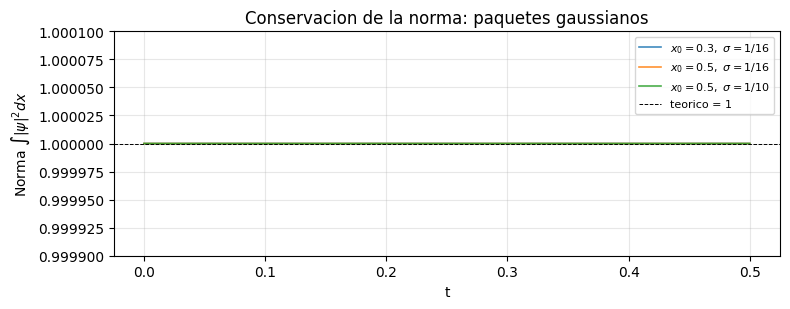

In [12]:
# Figura: conservacion de la norma de los tres paquetes gaussianos
fig, ax = plt.subplots(figsize=(8, 3.2))
casos_n = [('x03', r'$x_0=0.3,\ \sigma=1/16$', '#1f77b4'),
           ('x05', r'$x_0=0.5,\ \sigma=1/16$', '#ff7f0e'),
           ('x05s10', r'$x_0=0.5,\ \sigma=1/10$', '#2ca02c')]
for nombre, label, color in casos_n:
    d = res_g[nombre]
    ax.plot(d['tiempos'], d['normas'], color=color, linewidth=1.2, label=label, alpha=0.85)
ax.axhline(1.0, color='k', linewidth=0.7, linestyle='--', label='teorico = 1')
ax.set_xlabel('t'); ax.set_ylabel(r'Norma $\int|\psi|^2dx$')
ax.set_title('Conservacion de la norma: paquetes gaussianos')
ax.set_ylim(0.9999, 1.0001); ax.ticklabel_format(axis='y', useOffset=False)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig_gaussiana_norma.png', dpi=150, bbox_inches='tight')
plt.show()

x03 clasico B (iso-energetico): <V>0=419.5  <T>0=128.0  <H>0=547.5  -> x0=0.2952, p0=11.31, amplitud=0.234 (vs Ehrenfest 0.200)


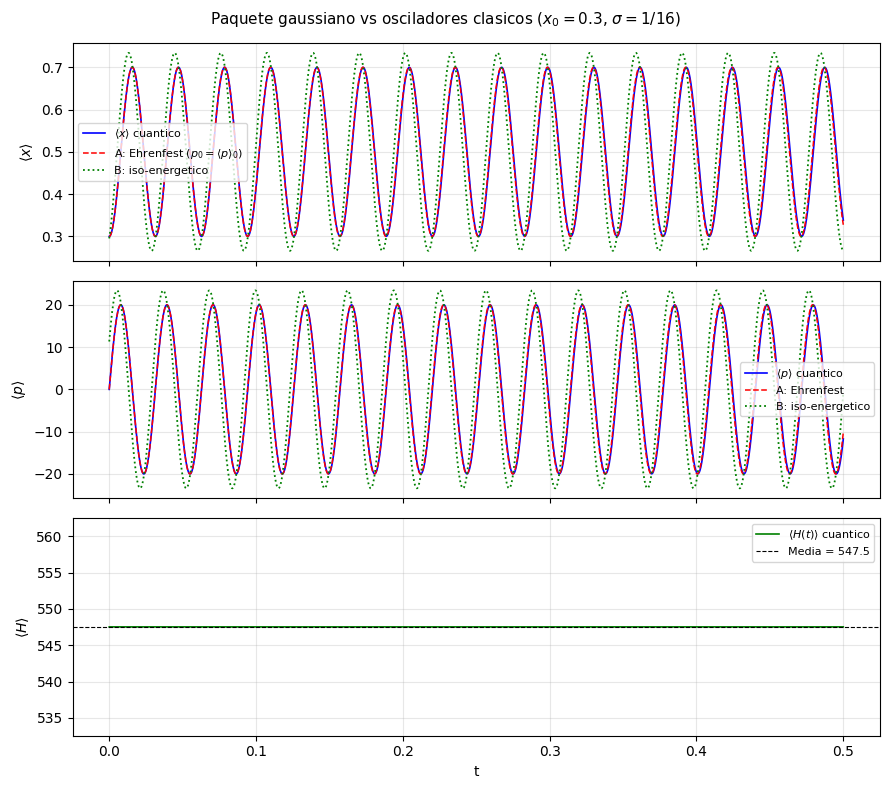

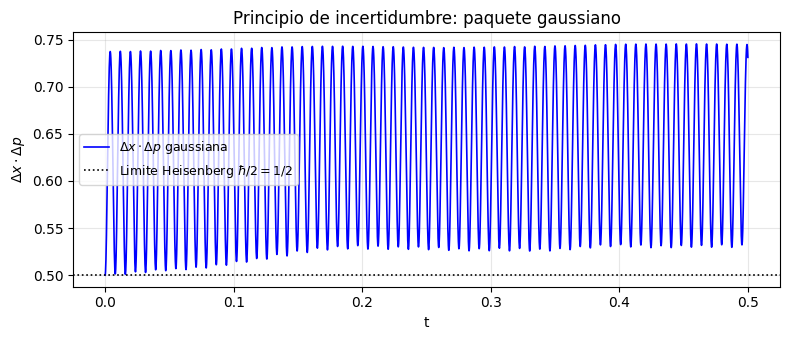

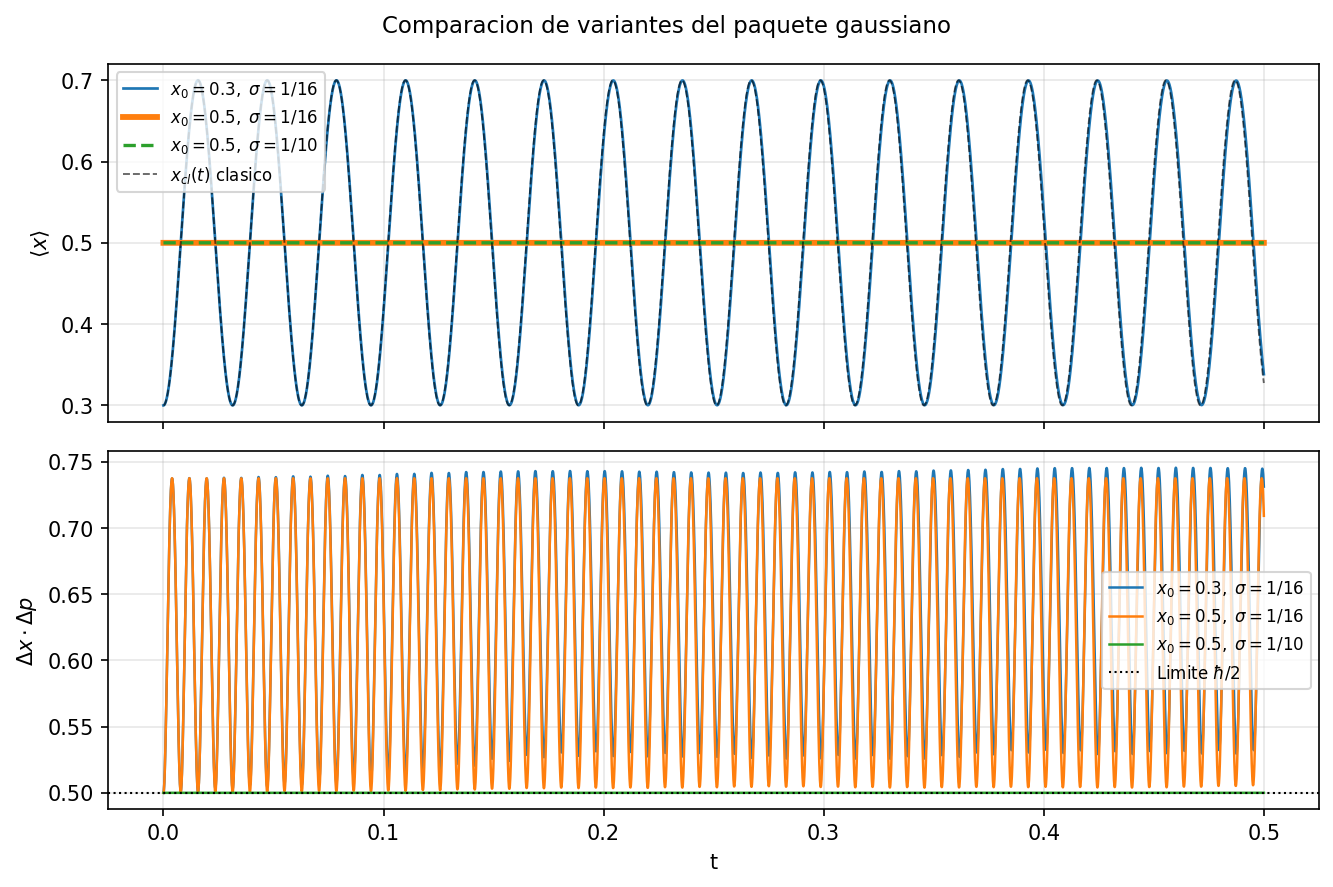

In [13]:
# Figura 6: <x>, <p>, <H> del paquete x0=0.3 frente a DOS osciladores clasicos.
#   A (Ehrenfest):     x0=<x>0, p0=<p>0=0  -> por Ehrenfest sigue a <x(t)> exactamente.
#   B (iso-energetico): misma KE y PE inicial que el cuantico (lo que pide el enunciado).
#                       Como tiene KE!=0 necesita p0=sqrt(<T>0) y su amplitud es mayor.
d = res_g['x03']
psi0 = d['frames'][0]
V0 = h * np.sum(V_pot * np.abs(psi0)**2)        # energia potencial inicial <V>0
H0 = d['H_meds'][0]                              # energia total inicial <H>0
T0 = H0 - V0                                     # energia cinetica inicial <T>0 (de la dispersion)
xB0 = x_c - (2.0 / omega) * np.sqrt(V0)          # posicion con V(xB0)=<V>0 (mismo lado que el paquete)
pB0 = np.sqrt(T0)                                # KE=p^2 (m=1/2) -> p0=sqrt(<T>0)
xB, pB = trayectoria_clasica(d['tiempos'], xB0, pB0)
print(f"x03 clasico B (iso-energetico): <V>0={V0:.1f}  <T>0={T0:.1f}  <H>0={H0:.1f}  "
      f"-> x0={xB0:.4f}, p0={pB0:.2f}, amplitud={2*np.sqrt(H0)/omega:.3f} "
      f"(vs Ehrenfest {abs(0.3-x_c):.3f})")

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
fig.suptitle(r'Paquete gaussiano vs osciladores clasicos ($x_0=0.3$, $\sigma=1/16$)', fontsize=11)

axes[0].plot(d['tiempos'], d['x_meds'], 'b-', linewidth=1.2, label=r'$\langle x\rangle$ cuantico')
axes[0].plot(d['tiempos'], d['x_cl'], 'r--', linewidth=1.1, label=r'A: Ehrenfest ($p_0=\langle p\rangle_0$)')
axes[0].plot(d['tiempos'], xB, color='green', linestyle=':', linewidth=1.3, label=r'B: iso-energetico')
axes[0].set_ylabel(r'$\langle x\rangle$'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(d['tiempos'], d['p_meds'], 'b-', linewidth=1.2, label=r'$\langle p\rangle$ cuantico')
axes[1].plot(d['tiempos'], d['p_cl'], 'r--', linewidth=1.1, label=r'A: Ehrenfest')
axes[1].plot(d['tiempos'], pB, color='green', linestyle=':', linewidth=1.3, label=r'B: iso-energetico')
axes[1].set_ylabel(r'$\langle p\rangle$'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(d['tiempos'], d['H_meds'], 'g-', linewidth=1.2, label=r'$\langle H(t)\rangle$ cuantico')
axes[2].axhline(d['H_meds'].mean(), color='k', linewidth=0.8, linestyle='--',
                label=f"Media = {d['H_meds'].mean():.1f}")
axes[2].set_ylabel(r'$\langle H\rangle$'); axes[2].set_xlabel('t')
axes[2].set_ylim(d['H_meds'].mean() - 15, d['H_meds'].mean() + 15)
axes[2].ticklabel_format(axis='y', useOffset=False)
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resultados/informe/fig06_gaussiana_observables.png', dpi=150, bbox_inches='tight')
plt.show()

# Figura 7: principio de incertidumbre del paquete x0=0.3
d = res_g['x03']
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(d['tiempos'], d['dxdps'], 'b-', linewidth=1.2, label=r'$\Delta x\cdot\Delta p$ gaussiana')
ax.axhline(0.5, color='k', linestyle=':', linewidth=1.2, label=r'Limite Heisenberg $\hbar/2=1/2$')
ax.set_xlabel('t'); ax.set_ylabel(r'$\Delta x\cdot\Delta p$')
ax.set_title('Principio de incertidumbre: paquete gaussiano')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig07_gaussiana_heisenberg.png', dpi=150, bbox_inches='tight')
plt.show()

# Figura 8: comparacion de las tres variantes
casos = [('x03', r'$x_0=0.3,\ \sigma=1/16$', '#1f77b4', 1.3, '-'),
         ('x05', r'$x_0=0.5,\ \sigma=1/16$', '#ff7f0e', 2.8, '-'),
         ('x05s10', r'$x_0=0.5,\ \sigma=1/10$', '#2ca02c', 1.6, '--')]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle('Comparacion de variantes del paquete gaussiano', fontsize=11)
# En <x> (arriba) x05 y x05s10 coinciden en 0.5: naranja gruesa + verde discontinua para
# verlas ambas. En dxdp (abajo) las curvas oscilan rapido, se mantiene linea fina uniforme.
for nombre, label, color, lw, ls in casos:
    d = res_g[nombre]
    axes[0].plot(d['tiempos'], d['x_meds'], color=color, linewidth=lw, linestyle=ls, label=label)
    axes[1].plot(d['tiempos'], d['dxdps'], color=color, linewidth=1.2, label=label)
axes[0].plot(res_g['x03']['tiempos'], res_g['x03']['x_cl'], 'k--', linewidth=0.9, alpha=0.6,
             label=r'$x_{cl}(t)$ clasico')
axes[0].set_ylabel(r'$\langle x\rangle$'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='k', linestyle=':', linewidth=1.0, label=r'Limite $\hbar/2$')
axes[1].set_ylabel(r'$\Delta x\cdot\Delta p$'); axes[1].set_xlabel('t')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig08_gaussiana_variantes.png', dpi=150, bbox_inches='tight')
plt.show()

base (w=200, s=1/16): <H>0=547.5  norma_err=8.8e-13
w100 (w=100, s=1/16): <H>0=232.9  norma_err=5.3e-13  sigma_coh=0.1414  periodo=0.0628
s08  (w=200, s=1/8):  <H>0=524.0  norma_err=6.8e-13  sigma/sigma_coh=1.25


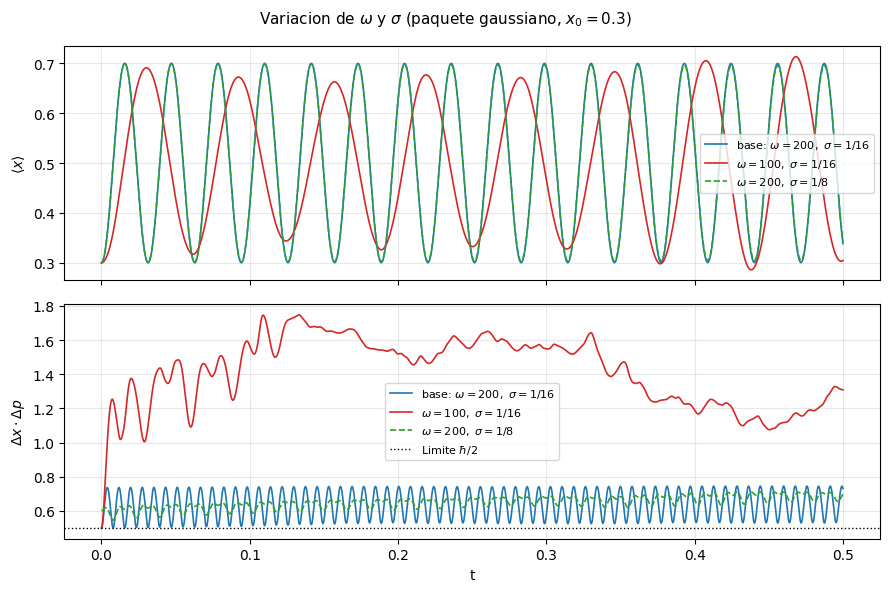

In [14]:
# ============================================================
# Figura 9: variacion de omega y sigma del paquete gaussiano (x0 = 0.3)
# Se comparan tres configuraciones. Como el potencial V(x)=(omega^2/4)(x-x_c)^2
# y la diagonal A0_diag del sistema tridiagonal DEPENDEN de omega, para cada
# variante se reconstruyen en su sitio (V_pot[:], A0_diag[:]), se recomputan los
# coeficientes de Thomas y se evoluciona. Al terminar se RESTAURAN al valor base
# (omega=200) para no contaminar las celdas posteriores (GIFs, conclusiones).
# ============================================================

# Estado base que hay que restaurar al final
V_pot_base   = V_pot.copy()
A0_diag_base = A0_diag.copy()
omega_base   = omega

def evolucion_variante(omega_v, sigma_v, x0_v=0.3):
    """
    Evoluciona un paquete gaussiano con frecuencia omega_v y anchura sigma_v.
    El nucleo de Cayley y los observables leen V_pot y A0_diag como globales, asi
    que se reconstruyen para esta omega antes de integrar. Devuelve las series
    <x(t)> y Dx.Dp(t) mas diagnosticos (energia inicial, anchura coherente, periodo).
    """
    global omega
    omega = omega_v
    V_pot[:]   = (omega_v**2 / 4.0) * (x - x_c)**2
    A0_diag[:] = -2.0 + (2.0j / s_tilde) - (h**2) * V_pot
    alpha_v = calcular_alpha(A0_diag, N)
    sim = SimuladorOAC.gaussiana(x0_v, sigma_v, alpha_v)
    d = sim.evolucionar(n_pasos, GUARDAR_CADA)
    d['H0']        = d['H_meds'][0]
    d['sigma_coh'] = np.sqrt(2.0 / omega_v)   # anchura del estado coherente: sqrt(2/omega)
    d['periodo']   = 2.0 * np.pi / omega_v     # T = 2 pi / omega
    return d

# Caso base (omega=200, sigma=1/16): ya evolucionado en res_g['x03']
d_base = res_g['x03']
# Variantes
d_w100 = evolucion_variante(100.0, 1.0 / 16.0)   # mitad de frecuencia
d_s08  = evolucion_variante(200.0, 1.0 / 8.0)     # doble de anchura

# Restaurar el estado base para las celdas siguientes
omega = omega_base
V_pot[:]   = V_pot_base
A0_diag[:] = A0_diag_base

# Diagnosticos
print(f"base (w=200, s=1/16): <H>0={d_base['H_meds'][0]:.1f}  "
      f"norma_err={np.max(np.abs(d_base['normas']-1)):.1e}")
print(f"w100 (w=100, s=1/16): <H>0={d_w100['H0']:.1f}  "
      f"norma_err={np.max(np.abs(d_w100['normas']-1)):.1e}  "
      f"sigma_coh={d_w100['sigma_coh']:.4f}  periodo={d_w100['periodo']:.4f}")
print(f"s08  (w=200, s=1/8):  <H>0={d_s08['H0']:.1f}  "
      f"norma_err={np.max(np.abs(d_s08['normas']-1)):.1e}  "
      f"sigma/sigma_coh={(1.0/8.0)/d_s08['sigma_coh']:.2f}")

# Figura 9: <x(t)> (arriba) y Dx.Dp (abajo) para las tres configuraciones
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.suptitle(r'Variacion de $\omega$ y $\sigma$ (paquete gaussiano, $x_0=0.3$)', fontsize=11)
curvas = [(d_base, r'base: $\omega=200,\ \sigma=1/16$', '#1f77b4', '-'),
          (d_w100, r'$\omega=100,\ \sigma=1/16$',       '#d62728', '-'),
          (d_s08,  r'$\omega=200,\ \sigma=1/8$',        '#2ca02c', '--')]
for d, label, color, ls in curvas:
    axes[0].plot(d['tiempos'], d['x_meds'], color=color, linestyle=ls, linewidth=1.2, label=label)
    axes[1].plot(d['tiempos'], d['dxdps'],  color=color, linestyle=ls, linewidth=1.2, label=label)
axes[0].set_ylabel(r'$\langle x\rangle$'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='k', linestyle=':', linewidth=1.0, label=r'Limite $\hbar/2$')
axes[1].set_ylabel(r'$\Delta x\cdot\Delta p$'); axes[1].set_xlabel('t')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/informe/fig09_variacion_params.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# GIFs del paquete gaussiano (con la posicion clasica superpuesta en |psi|^2)
for nombre, label in [('x03', 'x0=0.3'), ('x05', 'x0=0.5'), ('x05s10', 'x0=0.5, sigma=1/10')]:
    d = res_g[nombre]
    x_cl_frames = d['x_cl'][::GUARDAR_CADA][:len(d['t_frames'])]
    print(f'Generando GIFs gaussiana {label}...')
    gif_reIm(d['frames'], d['t_frames'], f'OAC gaussiana {label} - Re/Im',
             f'resultados/gaussiana/{nombre}_reIm.gif')
    gif_probabilidad(d['frames'], d['t_frames'], f'OAC gaussiana {label} - Probabilidad',
             f'resultados/gaussiana/{nombre}_prob.gif', x_cl=x_cl_frames)

Generando GIFs gaussiana x0=0.3...


  guardado x03_reIm.gif


  guardado x03_prob.gif
Generando GIFs gaussiana x0=0.5...


  guardado x05_reIm.gif


  guardado x05_prob.gif
Generando GIFs gaussiana x0=0.5, sigma=1/10...


  guardado x05s10_reIm.gif


  guardado x05s10_prob.gif


---
# Conclusiones

1. **Norma exacta.** El algoritmo de Cayley conserva la norma con error $<2\times10^{-12}$
   (precisión de máquina): el operador de evolución discreto es unitario, a diferencia de Euler.
2. **Estados estacionarios.** Para $n=0,1,2,3$: $\langle H\rangle=E_n=\omega(n+\tfrac12)$ con
   error $<0.002\%$; $\langle x\rangle=0.5$ y $\langle p\rangle=0$; y $\Delta x\,\Delta p=(2n+1)/2$,
   saturando el límite de Heisenberg en $n=0$.
3. **Correspondencia de Bohr.** Ya para $n=20$ la envolvente de $|\phi_n|^2$ reproduce la
   distribución clásica $P_{cl}(x)$, que diverge en los puntos de retorno.
4. **Ehrenfest.** El centroide del paquete gaussiano sigue la trayectoria clásica; la pequeña
   desviación proviene del error de discretización $\mathcal{O}(\Delta x^2)$ del Hamiltoniano.
5. **Estado coherente.** El paquete con $\sigma=1/\sqrt{\omega/2}=0.1$ mantiene
   $\Delta x\,\Delta p=1/2$ constante, el estado cuántico más parecido al clásico.

Los GIFs de `Re/Im` y `|psi|^2` (carpetas `resultados/autofunciones/` y `resultados/gaussiana/`)
muestran visualmente la rotación de fase de los estados estacionarios y el movimiento oscilatorio
del paquete gaussiano.